In [21]:
import pandas as pd

In [22]:
df = pd.read_csv("raw_data.csv")
print(df)

    id          name   age country   gender   income
0    1      John Doe  29.0     USA     Male  55000.0
1    1      John Doe  29.0     USA     Male  55000.0
2    2    Jane Smith   NaN  Canada   Female  62000.0
3    3          Alex   NaN     USA  Unknown  47000.0
4    4  Maria Garcia  34.0   Spain   Female      NaN
5    5        Li Wei  27.0   China     Male  51000.0
6    6           NaN  45.0   India   Female  73000.0
7    7    Ahmed Khan  38.0     NaN     Male  68000.0
8    8    Rachel Lee  29.0     USA   Female  62000.0
9    9   Carlos Ruiz   NaN  Mexico     Male  45000.0
10  10   Emily Davis  31.0     USA      NaN  58000.0


In [23]:
df2 = df.copy()

df2["tax"] = df2["income"].apply(lambda x : "20%" if x >= 60000 else "10%")

df2.assign(new_income = df2["income"] * 1.1)

df2["country"] = df2["country"].replace("USA", "US")


# Data Tranform
df2.columns = ["Id", "Name", "Age", "Country", "Gender", "New Income","Tax"]
df2.rename(columns={"New Income":"Salary"})


df2.sort_values("New Income")
df2 = df2.fillna(50)
# df2.sort_values(["New Income", "Age"])

sorted_df = df2.sort_values(["New Income", "Age"])
sorted_df.sort_index()

# Ranking 
sorted_df["Ranking"] = sorted_df["New Income"].rank(ascending=False, method="min")

sorted_df
# df2

,Id,Name,Age,Country,Gender,New Income,Tax,Ranking
4,4,Maria Garcia,34.0,Spain,Female,50.0,10%,11.0
9,9,Carlos Ruiz,50.0,Mexico,Male,45000.0,10%,10.0
3,3,Alex,50.0,US,Unknown,47000.0,10%,9.0
5,5,Li Wei,27.0,China,Male,51000.0,10%,8.0
0,1,John Doe,29.0,US,Male,55000.0,10%,6.0
1,1,John Doe,29.0,US,Male,55000.0,10%,6.0
10,10,Emily Davis,31.0,US,50,58000.0,10%,5.0
8,8,Rachel Lee,29.0,US,Female,62000.0,20%,3.0
2,2,Jane Smith,50.0,Canada,Female,62000.0,20%,3.0
7,7,Ahmed Khan,38.0,50,Male,68000.0,20%,2.0


In [24]:
df2 = df.copy()

new_col_order = [col for col in df2.columns if col != "id"] + ["id"]
print(new_col_order)
df2[new_col_order]

['name', 'age', 'country', 'gender', 'income', 'id']


,name,age,country,gender,income,id
0,John Doe,29.0,USA,Male,55000.0,1
1,John Doe,29.0,USA,Male,55000.0,1
2,Jane Smith,NaN,Canada,Female,62000.0,2
3,Alex,NaN,USA,Unknown,47000.0,3
4,Maria Garcia,34.0,Spain,Female,NaN,4
5,Li Wei,27.0,China,Male,51000.0,5
6,NaN,45.0,India,Female,73000.0,6
7,Ahmed Khan,38.0,NaN,Male,68000.0,7
8,Rachel Lee,29.0,USA,Female,62000.0,8
9,Carlos Ruiz,NaN,Mexico,Male,45000.0,9


In [27]:
df2 = df.copy()

df2 = df2.drop_duplicates()
df2 = df2.fillna(0)

df2 = df2.sort_values("income")
df2 = df2.reset_index(drop=True)
df.to_csv("sorted_data.csv")

In [28]:
df

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


In [52]:
df.groupby("country")["income"].mean()
df.groupby("country")["income"].min()
df.groupby("country")["income"].max()

df.groupby("gender")["income"].min()
df.groupby("gender")["income"].max()


df.groupby("gender")["income"].agg(["mean", "min", "max"])


df.groupby("gender")["income"].agg(avg_salary="mean", min_salary="min", max_salary="max")


df.groupby("country").agg({
    "income": "mean",
    "age": "mean"
})

df.groupby("country").agg({
    "income": "max",
    "age": "mean"
})

df.groupby("country").agg(
    max_salary=("income", "max"),
    avg_age=("age", "mean")
)

,max_salary,avg_age
country,,
Canada,62000.0,NaN
China,51000.0,27.0
India,73000.0,45.0
Mexico,45000.0,NaN
Spain,NaN,34.0
USA,62000.0,29.5


In [54]:
# Melt & Pivot

df = pd.DataFrame({
    "country": ["USA", "USA", "India", "India"],
    "year": [2020, 2021, 2020, 2021],
    "sales": [100, 120, 90, 110],
    "profit": [20, 25, 18, 22],
    "tax": [10, 20, 30, 40]
})

# df.melt(
#     id_vars=["country", "year"],
#     value_vars=["sales", "profit", "tax"],
#     var_name="metrics",
#     value_name="value"
# )
df.melt(
    id_vars=["country", "year"],
    value_vars=["sales", "profit", "tax"],
    var_name="metrics",
    value_name="value"
)

,country,year,metrics,value
0,USA,2020,sales,100
1,USA,2021,sales,120
2,India,2020,sales,90
3,India,2021,sales,110
4,USA,2020,profit,20
5,USA,2021,profit,25
6,India,2020,profit,18
7,India,2021,profit,22
8,USA,2020,tax,10
9,USA,2021,tax,20


<Axes: xlabel='Age', ylabel='Salary'>

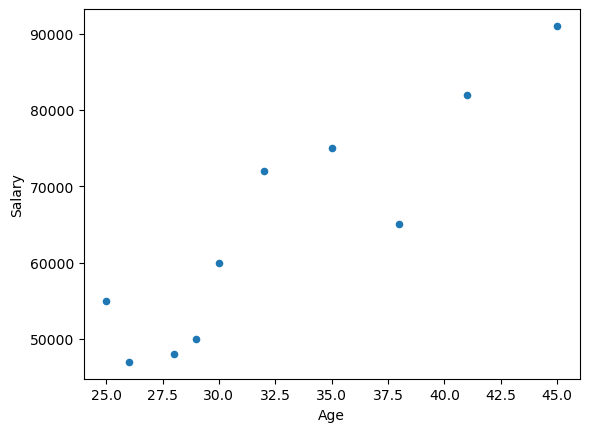

In [58]:
df = pd.read_csv("employee_data.csv")

# df["Age"].hist()

df.plot(kind="scatter", x="Age", y="Salary")

In [62]:
# concatentation
df1 = pd.DataFrame({
    "id" : [1, 2, 3],
    "name" : ["Adan", "Eve", "Bob"]
})

df2 = pd.DataFrame({
    "id" : [4, 5, 6],
    "name" : ["Charlie", "Fester", "Gilian"]
})

pd.concat([df1, df2]) #row
pd.concat([df1, df2], ignore_index=True) 

pd.concat([df1, df2], axis=1) #col 

,id,name,id,name
0,1,Adan,4,Charlie
1,2,Eve,5,Fester
2,3,Bob,6,Gilian
